In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.preprocessing import LabelEncoder
from scipy.linalg import lu

In [7]:
df = pd.read_csv("student_performance.csv")
df

,ID,Physics,Chemistry,Biology,Geography,Arts,Total_Score,Performance
0,S001,52,80,64,63,51,310,Low
1,S002,92,45,59,93,40,329,Low
2,S003,82,43,73,62,94,354,High
3,S004,67,60,59,81,53,320,Low
4,S005,81,42,67,38,92,320,Low
...,...,...,...,...,...,...,...,...
145,S146,72,38,79,75,71,335,Low
146,S147,84,74,57,53,65,333,Low
147,S148,60,86,83,65,67,361,High
148,S149,52,90,85,84,77,388,High


## 📘 Part A: Vector & Matrix Fundamentals

### 1. Representing each student's subject scores as a vector

In [ ]:
cols = ["Physics", "Chemistry", "Biology", "Geography", "Arts"]   # Select subject columns

s1 = np.array(df[cols].iloc[0])   # Create score vectors for first two students
s2 = np.array(df[cols].iloc[1])

print("Student S001 score vector:", s1)   
print("Student S002 score vector:", s2)

Student S001 score vector: [52 80 64 63 51]
Student S002 score vector: [92 45 59 93 40]


### 2. Compute Norm-1 and Norm-2

In [9]:
s1_n1 = np.linalg.norm(s1, ord=1)   # Calculate Norm-1 and Norm-2 for Student S001
s1_n2 = np.linalg.norm(s1, ord=2)

s2_n1 = np.linalg.norm(s2, ord=1)   # Calculate Norm-1 and Norm-2 for Student S002
s2_n2 = np.linalg.norm(s2, ord=2)

print("S001 - Norm 1:", s1_n1)
print("S001 - Norm 2:", s1_n2)
print()
print("S002 - Norm 1:", s2_n1)
print("S002 - Norm 2:", s2_n2)

S001 - Norm 1: 310.0
S001 - Norm 2: 140.60583202698243

S002 - Norm 1: 329.0
S002 - Norm 2: 155.62454819211524


### 3. Dot Product

In [11]:
dp = np.dot(s1, s2)   # Calculate Dot Product between two student vectors
print("Dot Product (S001 . S002):", dp)

Dot Product (S001 . S002): 20059


### 4. Angle Between Two Students

In [12]:
cos_val = dp / (np.linalg.norm(s1) * np.linalg.norm(s2))   # Calculate angle between the two vectors
theta = np.degrees(np.arccos(cos_val))
print("Angle between S001 and S002:", theta, "degrees")

Angle between S001 and S002: 23.55150080033014 degrees


### 5. Cross Product

In [13]:
s1_3d = s1[:3]   # Select first three subject scores to create 3D vectors
s2_3d = s2[:3]

cp = np.cross(s1_3d, s2_3d)   # Calculate Cross Product of the two vectors

print("S001 3D vector:", s1_3d)
print("S002 3D vector:", s2_3d)
print("Cross Product result:", cp)

S001 3D vector: [52 80 64]
S002 3D vector: [92 45 59]
Cross Product result: [ 1840  2820 -5020]


### 6. Projection

In [14]:
proj = (np.dot(s1, s2) / np.dot(s2, s2)) * s2   # Calculate projection of S001 onto S002

print("Projection of S001 onto S002:")
print(proj)

Projection of S001 onto S002:
[76.19753086 37.2705314  48.86580784 77.0257649  33.12936125]


## 📘 Part B: Matrix Operations

### 7. Form Student × Subject Matrix

In [17]:
cols = ["Physics", "Chemistry", "Biology", "Geography", "Arts"]   # Select subject columns

score_matrix = df[cols].values   # Create Student × Subject Matrix

print("Student × Subject Matrix:")
print(score_matrix)

print("Matrix Shape:", score_matrix.shape)

Student × Subject Matrix:
[[52 80 64 63 51]
 [92 45 59 93 40]
 [82 43 73 62 94]
 [67 60 59 81 53]
 [81 42 67 38 92]
 [60 74 97 36 74]
 [71 73 88 98 79]
 [84 40 85 63 76]
 [90 44 86 81 58]
 [37 75 86 49 56]
 [74 56 90 72 87]
 [82 85 35 83 58]
 [96 71 65 74 59]
 [83 79 55 50 51]
 [42 96 58 68 69]
 [87 49 53 40 90]
 [62 58 95 87 62]
 [69 97 94 55 68]
 [75 63 59 63 99]
 [38 59 54 36 37]
 [99 50 60 60 93]
 [69 84 41 78 90]
 [93 39 90 52 56]
 [45 56 45 64 76]
 [57 67 51 57 38]
 [53 74 81 82 46]
 [50 36 78 89 71]
 [62 70 98 57 75]
 [65 93 64 74 92]
 [87 73 77 98 97]
 [61 36 50 48 39]
 [41 87 38 36 51]
 [49 52 84 38 62]
 [89 80 68 43 61]
 [36 57 69 50 87]
 [78 88 98 66 60]
 [93 35 47 61 83]
 [90 70 61 49 94]
 [60 74 75 59 61]
 [85 64 76 49 72]
 [91 54 63 46 43]
 [84 72 50 58 66]
 [47 36 87 75 35]
 [53 40 80 94 43]
 [36 70 71 65 84]
 [86 60 94 55 71]
 [79 93 49 94 40]
 [83 64 55 48 71]
 [91 56 68 48 73]
 [84 51 43 58 38]
 [38 65 60 59 83]
 [46 90 52 62 71]
 [56 65 35 52 44]
 [38 47 57 91 42]
 [

### 8. Matrix Addition and Multiplication

In [ ]:
mat_a = df[cols].iloc[0:5].values   # Create Matrix A using first 5 students

mat_b = df[cols].iloc[5:10].values   # Create Matrix B using next 5 students

mat_add = mat_a + mat_b   # Add the two matrices

print("Matrix Addition:")
print(mat_add)

mat_mul = np.dot(mat_a, mat_b.T)   # Multiply Matrix A with transpose of Matrix B

print("\nMatrix Multiplication:")
print(mat_mul)

Matrix Addition:
[[112 154 161  99 125]
 [163 118 147 191 119]
 [166  83 158 125 170]
 [157 104 145 162 111]
 [118 117 153  87 148]]

Matrix Multiplication:
[[21290 25367 20853 21765 19371]
 [20881 27283 23442 25187 18650]
 [24371 28887 25863 26024 20839]
 [21021 26454 22174 23379 18990]
 [22643 25705 23565 23314 18923]]


### 9. Transpose of the Score Matrix

In [21]:
mat_T = score_matrix.T   # Create the transpose of the score matrix

print("Original Shape:", score_matrix.shape)   
print("Transposed Shape:", mat_T.shape)
print()
print("Transposed Matrix:")
print(mat_T)

Original Shape: (150, 5)
Transposed Shape: (5, 150)

Transposed Matrix:
[[52 92 82 67 81 60 71 84 90 37 74 82 96 83 42 87 62 69 75 38 99 69 93 45
  57 53 50 62 65 87 61 41 49 89 36 78 93 90 60 85 91 84 47 53 36 86 79 83
  91 84 38 46 56 38 46 38 41 44 49 47 89 62 73 52 96 82 51 40 81 50 94 75
  60 80 84 35 70 64 36 65 42 95 79 86 42 48 63 98 71 75 98 93 43 41 75 60
  42 48 79 36 76 91 98 38 52 85 37 53 81 80 92 70 53 81 89 97 46 61 45 38
  80 93 94 58 60 62 92 38 94 83 91 39 91 95 44 68 44 63 45 38 83 38 58 90
  69 72 84 60 52 93]
 [80 45 43 60 42 74 73 40 44 75 56 85 71 79 96 49 58 97 63 59 50 84 39 56
  67 74 36 70 93 73 36 87 52 80 57 88 35 70 74 64 54 72 36 40 70 60 93 64
  56 51 65 90 65 47 51 73 42 72 49 35 37 72 82 97 96 49 96 72 54 93 41 86
  38 35 72 87 37 49 37 67 90 67 65 38 56 65 94 66 42 96 62 51 36 42 72 54
  98 55 65 49 91 35 63 56 95 63 43 75 55 89 74 60 82 37 67 76 77 38 98 85
  52 54 64 86 57 81 37 84 43 53 70 74 61 55 47 61 96 74 87 74 43 61 37 90
  87 38 74 86 90 99

### 10. Determinant and Inverse

In [24]:
square_matrix = df[cols].head(5).values   # Create a 5×5 square matrix

det_val = np.linalg.det(square_matrix)   # Calculate determinant
print("Determinant:", det_val)

if abs(det_val) > 1e-6:

    mat_inv = np.linalg.inv(square_matrix)

    print("\nInverse Matrix:")
    print(mat_inv)

else:
    print("Matrix is singular - inverse not possible")

Determinant: -32010812.000000093

Inverse Matrix:
[[-0.01972549  0.01096736 -0.05967846  0.02320138  0.05377617]
 [-0.0127336  -0.02267803 -0.06842688  0.06520319  0.04927057]
 [ 0.10127081  0.06383687  0.1377056  -0.20843092 -0.10451928]
 [-0.02045503 -0.01207067  0.01445074  0.04138208 -0.02201725]
 [-0.04212258 -0.04080721 -0.02247303  0.08450551  0.02624145]]


## 📘 Part C: Linear Transformation & Geometry

### 11. Line, Plane and Hyperplane with dataset

In [ ]:
print("Line (1D) - Physics scores of first 5 students:")  
print(df["Physics"].head(5).values)

print()

print("Plane (2D) - Physics and Chemistry scores:")   
print(df[["Physics", "Chemistry"]].head(5).values)

print()

print("Hyperplane (5D) - All subject scores:")   
print(df[cols].head(5).values)

Line (1D) - Physics scores of first 5 students:
[52 92 82 67 81]

Plane (2D) - Physics and Chemistry scores:
[[52 80]
 [92 45]
 [82 43]
 [67 60]
 [81 42]]

Hyperplane (5D) - All subject scores:
[[52 80 64 63 51]
 [92 45 59 93 40]
 [82 43 73 62 94]
 [67 60 59 81 53]
 [81 42 67 38 92]]


### 12. Dimensionality from 2D to 3D to 5D

In [ ]:
print("2D - Physics and Chemistry:")   # Represent data in 2 dimensions using Physics and Chemistry
print(df[["Physics", "Chemistry"]].head(3).values)

print()

print("3D - Adding Biology as third dimension:")   # Represent data in 3 dimensions by adding Biology
print(df[["Physics", "Chemistry", "Biology"]].head(3).values)

print()

print("5D - All 5 subjects (hyperplane):")   # Represent data in 5 dimensions using all subjects

print(df[cols].head(3).values)

print()

print("Each new subject adds one more dimension to the data.")   

2D - Physics and Chemistry:
[[52 80]
 [92 45]
 [82 43]]

3D - Adding Biology as third dimension:
[[52 80 64]
 [92 45 59]
 [82 43 73]]

5D - All 5 subjects (hyperplane):
[[52 80 64 63 51]
 [92 45 59 93 40]
 [82 43 73 62 94]]

Each new subject adds one more dimension to the data.


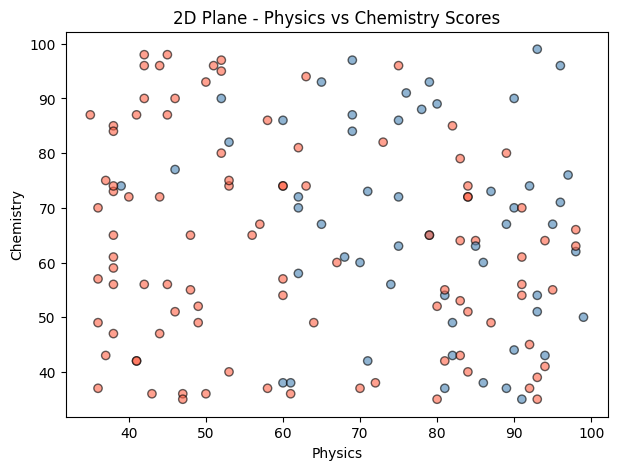

In [ ]:
plt.figure(figsize=(7, 5))   # Visualize Physics and Chemistry scores on a 2D plane

colors = ["steelblue" if p == "High" else "tomato"   
          for p in df["Performance"]]   # Assign colors based on performance category

# Create scatter plot
plt.scatter(
    df["Physics"],
    df["Chemistry"],
    c=colors,
    edgecolors="black",
    alpha=0.6
)

plt.title("2D Plane - Physics vs Chemistry Scores")   
plt.xlabel("Physics")
plt.ylabel("Chemistry")
plt.show()

## 📘 Part D: Eigenvalues & Eigenvectors

### 13. Eigenvalues and Eigenvectors of Covariance Matrix

In [ ]:
cov_mat = np.cov(df[cols].values.T)   # Calculate covariance matrix from subject scores

eig_vals, eig_vecs = np.linalg.eig(cov_mat)   # Compute eigenvalues and eigenvectors

print("Covariance Matrix Shape:", cov_mat.shape)   
print()

print("Eigenvalues:")   
print(eig_vals)
print()

print("Eigenvectors:")   
print(eig_vecs)

Covariance Matrix Shape: (5, 5)

Eigenvalues:
[473.90972901 247.51182466 377.82732093 297.05997985 317.14859522]

Eigenvectors:
[[ 0.71328818 -0.35572552  0.50635093 -0.29246181 -0.15084477]
 [-0.54880175 -0.5486364   0.5188623   0.31528604 -0.1708548 ]
 [ 0.04596396 -0.72513689 -0.67061452 -0.12367828 -0.08392647]
 [ 0.26902041  0.14734275 -0.15673157  0.58447276 -0.73467336]
 [ 0.33992931 -0.15787357 -0.01010065  0.67687228  0.63345552]]


### 14. LU Decomposition

In [ ]:
m = df[cols].head(5).values.astype(float)   # Create a 5×5 square matrix using first 5 students

P, L, U = lu(m)   # Perform LU Decomposition

print("Original Matrix:")
print(m)
print()
print("L (Lower Triangular):")  
print(L)
print()
print("U (Upper Triangular):")   
print(U)

Original Matrix:
[[52. 80. 64. 63. 51.]
 [92. 45. 59. 93. 40.]
 [82. 43. 73. 62. 94.]
 [67. 60. 59. 81. 53.]
 [81. 42. 67. 38. 92.]]

L (Lower Triangular):
[[ 1.          0.          0.          0.          0.        ]
 [ 0.56521739  1.          0.          0.          0.        ]
 [ 0.89130435  0.05298805  1.          0.          0.        ]
 [ 0.88043478  0.0436255   0.73006785  1.          0.        ]
 [ 0.72826087  0.49900398  0.03922816 -0.31052941  1.        ]]

U (Upper Triangular):
[[ 92.          45.          59.          93.          40.        ]
 [  0.          54.56521739  30.65217391  10.43478261  28.39130435]
 [  0.           0.          18.78884462 -21.44422311  56.84342629]
 [  0.           0.           0.         -28.67991942  14.04446565]
 [  0.           0.           0.           0.          11.83354787]]


### 15. Singular Value Decomposition (SVD)

In [ ]:
scores = df[cols].values.astype(float)   # Create score matrix using all subject scores

U_m, S_vals, Vt_m = np.linalg.svd(scores, full_matrices=False)   # Perform Singular Value Decomposition (SVD)

print("Singular Values:")   
print()
print("U shape:", U_m.shape)   
print("Vt shape:", Vt_m.shape)
print()
print("Top singular value explains the most variance in the data")

Singular Values:
[1839.82044061  257.50083801  237.01705743  216.58934441  203.85787972]

U shape: (150, 5)
Vt shape: (5, 5)

Top singular value explains the most variance in the data


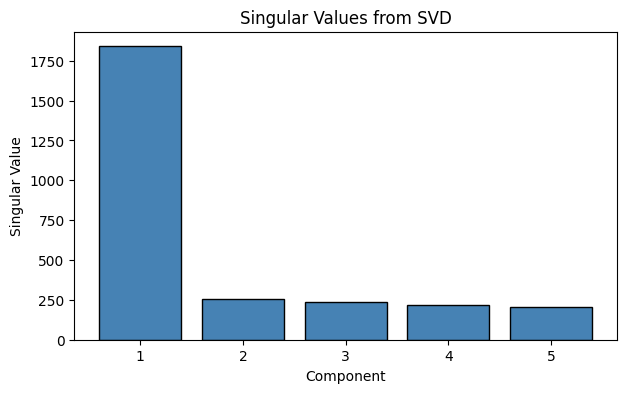

In [44]:
plt.figure(figsize=(7, 4))   # Visualize singular values obtained from SVD

# Create bar chart of singular values
plt.bar(
    range(1, len(S_vals) + 1),
    S_vals,
    color="steelblue",
    edgecolor="black"
)

plt.title("Singular Values from SVD")
plt.xlabel("Component")
plt.ylabel("Singular Value")
plt.show()

## Part E - Dimensionality Reduction

### 16. PCA - Reducing 5 subjects to 2 dimensions

In [ ]:
scores = df[cols].values   # Create score matrix using subject scores

pca_model = PCA(n_components=2)   # Apply PCA and reduce dimensions from 5 to 2
pca_scores = pca_model.fit_transform(scores)

print("Before PCA:", scores.shape)   
print("After PCA:", pca_scores.shape)
print()

print("Variance Explained:", pca_model.explained_variance_ratio_)   

print("Total:", sum(pca_model.explained_variance_ratio_))   

Before PCA: (150, 5)
After PCA: (150, 2)

Variance Explained: [0.27658097 0.22050581]
Total: 0.49708678211206114


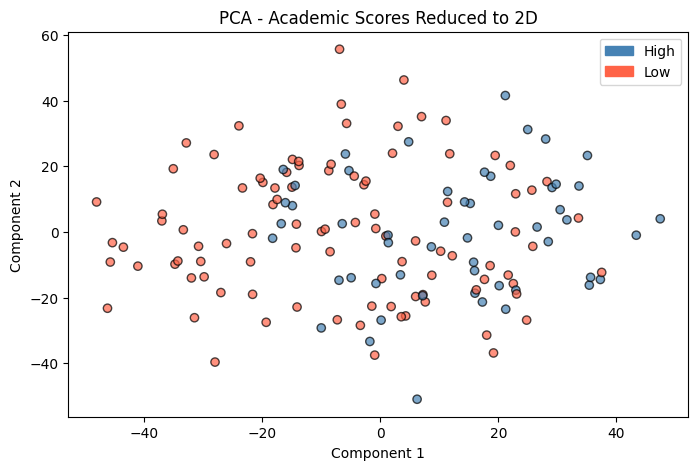

In [46]:
plt.figure(figsize=(8, 5))   # Visualize PCA results in 2D

# Assign colors based on performance category
clrs = ["steelblue" if p == "High" else "tomato"
        for p in df["Performance"]]

# Create PCA scatter plot
plt.scatter(
    pca_scores[:, 0],
    pca_scores[:, 1],
    c=clrs,
    edgecolors="black",
    alpha=0.7
)

plt.title("PCA - Academic Scores Reduced to 2D")
plt.xlabel("Component 1")
plt.ylabel("Component 2")

import matplotlib.patches as mpatches

h = mpatches.Patch(color="steelblue", label="High")
l = mpatches.Patch(color="tomato", label="Low")

plt.legend(handles=[h, l])
plt.show()

### 17. LDA - Classifying students into High and Low performance

In [ ]:
enc = LabelEncoder()   # Convert Performance labels (High/Low) into numeric values
lbs = enc.fit_transform(df["Performance"])

lda_model = LDA(n_components=1)   # Apply Linear Discriminant Analysis (LDA)
lda_scores = lda_model.fit_transform(scores, lbs)

print("Before LDA:", scores.shape)   
print("After LDA:", lda_scores.shape)
print()
print("Classes:", enc.classes_)   

Before LDA: (150, 5)
After LDA: (150, 1)

Classes: ['High' 'Low']


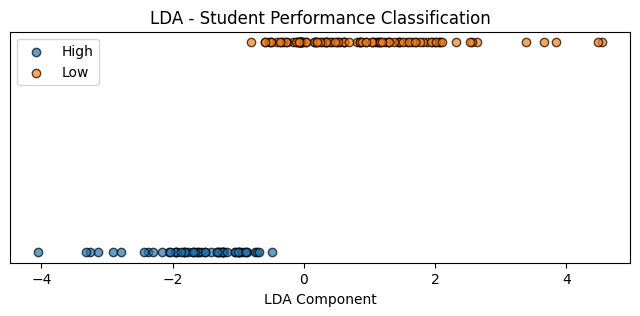

In [48]:
plt.figure(figsize=(8, 3))   # Visualize LDA results for student classification

for i, cat in enumerate(enc.classes_):   # Plot each performance category separately

    idx = df["Performance"] == cat

    plt.scatter(
        lda_scores[idx],
        np.zeros(idx.sum()) + i * 0.1,
        label=cat,
        alpha=0.7,
        edgecolors="black"
    )

plt.title("LDA - Student Performance Classification")
plt.xlabel("LDA Component")
plt.yticks([])
plt.legend()
plt.show()